# Лабораторная работа 3. Многомерная линейная регрессия

Загрузите датасет players.csv из папки datasets

Предсказываем overall

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv('players.csv')
df.head()

,sofifa_id,overall,value_eur,wage_eur,age,height_cm,weight_kg
0,158023,93,78000000.0,320000.0,34,170,72
1,188545,92,119500000.0,270000.0,32,185,81
2,20801,91,45000000.0,270000.0,36,187,83
3,190871,91,129000000.0,270000.0,29,175,68
4,192985,91,125500000.0,350000.0,30,181,70


In [69]:
df = df.dropna()
y = df['overall']
X = df.drop('overall', axis=1)
X.shape, y.shape

((19165, 6), (19165,))

# Задание 1
Проведите корреляционный анализ данных. Посчитайте коэффициенты парной корреляции между всеми признаками, нарисуйте heatmap.
Для признаков с максимальной по модулю корреляцией проведите анализ на наличие третьего фактора используя коэффициент частной корреляции.

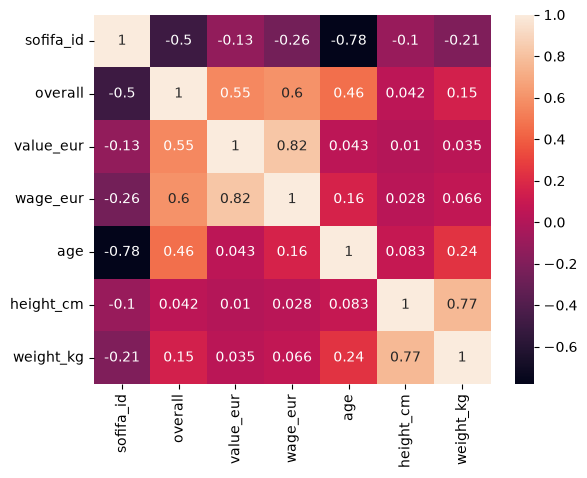

In [70]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [71]:
corr_abs = corr_matrix.abs()

corr_abs = corr_abs.mask(np.eye(corr_abs.shape[0], dtype=bool))

max_pair = corr_abs.stack().idxmax()

a = max_pair[0]
b = max_pair[1]

r = corr_matrix.loc[a, b]

print("Признаки с максимальной корреляцией:")
print(a, "и", b)
print("Коэффициент корреляции:", r)

Признаки с максимальной корреляцией:
value_eur и wage_eur
Коэффициент корреляции: 0.8235272246753316


In [72]:
import pingouin as pg

# Парная корреляция
r = df['value_eur'].corr(df['wage_eur'])

# Частная корреляция с учетом overall
result = pg.partial_corr(
    data=df,
    x='value_eur',
    y='wage_eur',
    covar='overall'
)

r_partial = result['r'].iloc[0]
p_value = result['p_val'].iloc[0]

print(f"Парная корреляция: r = {r:.3f}")
print(f"Частная корреляция: r = {r_partial:.3f}")
print(f"p-value = {p_value}")

Парная корреляция: r = 0.824
Частная корреляция: r = 0.737
p-value = 0.0


Таким образом, статистические значимо, поскольку p-value = 0.0. Проверялись признаки value_eur и wage_eur, связаны ли они признаком overall

# Задание 2
Разделите выборку на обучающую и тестовую, размер подберите сами. Произведите преобразование стандартизации.

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15332, 6), (3833, 6), (15332,), (3833,))

In [74]:
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Задание 3
Обучите следующие модели многомерной линейной регрессии:
1. Обычная многомерная линейная регрессия
2. Гребневая регрессия
3. Лассо регресиия

Для каждой модели выведите коэффициенты линейной регрессии. Какие из них статистически значимы? Посчитайте метрики MSE, MAE, R^2. Определите самые важные признаки.

In [77]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge().fit(X_train, y_train)
lasso = Lasso().fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

df_metrics = pd.DataFrame({
    "name": ['LinearRegression', 'Ridge', 'Lasso'],
    "MSE": [mean_squared_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_ridge), mean_squared_error(y_test, y_pred_lasso)],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_lasso)],
    "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
})
df_metrics

,name,MSE,MAE,R2
0,LinearRegression,22.171271,3.678839,0.525946
1,Ridge,22.171295,3.678858,0.525946
2,Lasso,24.179579,3.924555,0.483006


In [78]:
feature_names = [
    'sofifa_id',
    'value_eur',
    'wage_eur',
    'age',
    'height_cm',
    'weight_kg'
]

df_coef = pd.DataFrame({
    'feature': feature_names,
    'LinearRegression': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

df_coef

,feature,LinearRegression,Ridge,Lasso
0,sofifa_id,-1.308610,-1.308639,-0.976500
1,value_eur,2.010383,2.010264,1.199419
2,wage_eur,1.879698,1.879687,1.754204
3,age,1.691544,1.691430,1.094491
4,height_cm,-0.430913,-0.430812,0.000000
5,weight_kg,0.506443,0.506359,0.000000


In [79]:
df_coef['abs_LR'] = df_coef['LinearRegression'].abs()

df_coef.sort_values(
    'abs_LR',
    ascending=False
)

,feature,LinearRegression,Ridge,Lasso,abs_LR
1,value_eur,2.010383,2.010264,1.199419,2.010383
2,wage_eur,1.879698,1.879687,1.754204,1.879698
3,age,1.691544,1.691430,1.094491,1.691544
0,sofifa_id,-1.308610,-1.308639,-0.976500,1.308610
5,weight_kg,0.506443,0.506359,0.000000,0.506443
4,height_cm,-0.430913,-0.430812,0.000000,0.430913


In [80]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_sm).fit()

df_significance = pd.DataFrame({
    'feature': ['const'] + feature_names,
    'coefficient': model_sm.params,
    'p_value': model_sm.pvalues,
    'significant': model_sm.pvalues < 0.05
})

df_significance

,feature,coefficient,p_value,significant
const,const,65.791286,0.000000e+00,True
x1,sofifa_id,-1.308610,2.366472e-98,True
x2,value_eur,2.010383,4.670620e-191,True
x3,wage_eur,1.879698,2.430094e-160,True
x4,age,1.691544,1.470652e-162,True
x5,height_cm,-0.430913,4.260777e-13,True
x6,weight_kg,0.506443,1.042442e-16,True


# Задание 4
Для лучшей модели проведите анализ остатков. Для это необходимо нарисовать график предсказанные значения/остатки. Провести статистические тесты на нормальный закон и гетероскедастичность.

In [81]:
y_pred = lr.predict(X_test)

# остатки
residuals = y_test - y_pred

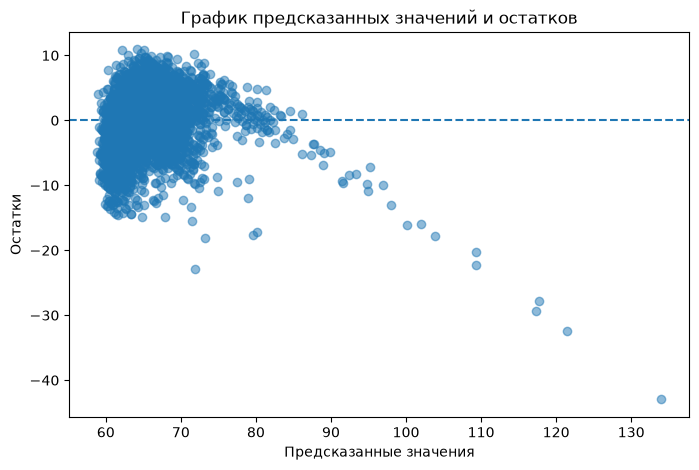

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График предсказанных значений и остатков')

plt.show()

In [85]:
from scipy.stats import normaltest

stat, p_value = normaltest(residuals)

print('Статистика:', stat)
print('p-value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Остатки НЕ имеют нормального распределения')
else:
    print('Нет оснований отвергать нормальность остатков')

Статистика: 673.7733126562438
p-value: 4.92021555729519e-147
Остатки НЕ имеют нормального распределения


In [87]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_sm = sm.add_constant(X_test)

bp_test = het_breuschpagan(residuals, X_test_sm)

labels = [
    'LM statistic',
    'LM p-value',
    'F statistic',
    'F p-value'
]

for label, value in zip(labels, bp_test):
    print(f'{label}: {value}')

if bp_test[1] < 0.05:
    print('Обнаружена гетероскедастичность')
else:
    print('Гетероскедастичность не обнаружена')

LM statistic: 848.3187824800376
LM p-value: 5.57176636120077e-180
F statistic: 181.24033049809364
F p-value: 1.332723255581617e-203
Обнаружена гетероскедастичность
